# Preprocessing v2 — Quality Filter + Erosion Volume

Extends the original preprocessing pipeline (`20260305_preprocess_region_split`) with:

1. **Quality audit** — show distribution of `estimate_reliability_height_model`
   (OK / NOK / MISSING_DATA) from the new `wocu_post_processed_fase2_20260310.gpkg`
2. **Quality filter** — keep only `OK` scope regions
3. **Erosion volume** — join `erosion_vol_train_m3` and `erosion_vol_test_m3`
   from `erosion_vlakken_filtered`
4. **Output** — save quality-filtered `region_split_v2.parquet` and
   `region_features_v2.parquet`

The bank-point processing (DataHandler) is unchanged — we load the
already-computed `processed_erosion_data.parquet` and only add the
new quality/volume data on top.


In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd()
for _p in [_cwd, _cwd.parent, _cwd.parent.parent]:
    if (_p / "src").is_dir():
        sys.path.insert(0, str(_p))
        break

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split

import src.paths as PATHS
import src.constants as CONST

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

# ── Paths ─────────────────────────────────────────────────────────────────────
GPKG_OLD        = PATHS.DATA_DIR / "01_raw/erosion/wocu_output_fase2_20260210.gpkg"
GPKG_NEW        = PATHS.DATA_DIR / "02_processed/erosion/wocu_post_processed_fase2_20260310.gpkg"

PROCESSED_IN    = PATHS.DATA_DIR / "02_processed/erosion/processed_erosion_data.parquet"
SPLIT_V1_PATH   = PATHS.DATA_DIR / "02_processed/erosion/region_split.parquet"

SPLIT_V2_OUT    = PATHS.DATA_DIR / "02_processed/erosion/region_split_v2.parquet"
FEATURES_V2_OUT = PATHS.DATA_DIR / "02_processed/erosion/region_features_v2.parquet"

QUALITY_COL  = "estimate_reliability_height_model"
DIST_COL     = CONST.DISTANCE_TO_CENTERLINE
RANDOM_SEED  = 42
TEST_SIZE    = 0.20
CLUSTERS     = ["ijssel1", "ijssel2", "maas1", "maas2", "maas3", "rijn", "nederrijn"]

def get_cluster(loc_id: str) -> str:
    for c in CLUSTERS:
        if loc_id.startswith(c):
            return c
    return "other"

print("Paths OK")
print(f"  OLD gpkg : {GPKG_OLD.name}  exists={GPKG_OLD.exists()}")
print(f"  NEW gpkg : {GPKG_NEW.name}  exists={GPKG_NEW.exists()}")
print(f"  processed: {PROCESSED_IN.name}  exists={PROCESSED_IN.exists()}")


Paths OK
  OLD gpkg : wocu_output_fase2_20260210.gpkg  exists=True
  NEW gpkg : wocu_post_processed_fase2_20260310.gpkg  exists=True
  processed: processed_erosion_data.parquet  exists=True


## 1. Quality audit — full scope

Loading summary_scope from new gpkg …

Scope regions in summary_scope: 16,772
  Label                 n       %
  OK                8,855   52.8%
  NOK               2,484   14.8%
  MISSING_DATA      5,433   32.4%


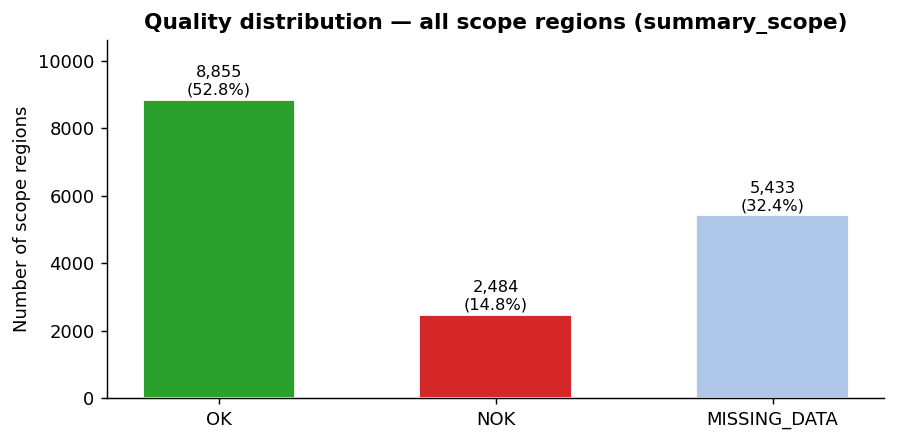

In [2]:
print("Loading summary_scope from new gpkg …")
scope_quality = gpd.read_file(str(GPKG_NEW), layer="summary_scope")
scope_quality = scope_quality.rename(columns={"position_id": "location_id"})

q_counts = scope_quality[QUALITY_COL].value_counts().reindex(["OK", "NOK", "MISSING_DATA"])
q_pct    = (q_counts / q_counts.sum() * 100).round(1)

print(f"\nScope regions in summary_scope: {len(scope_quality):,}")
print(f"  {'Label':<15}  {'n':>6}  {'%':>6}")
for label in ["OK", "NOK", "MISSING_DATA"]:
    print(f"  {label:<15}  {int(q_counts[label]):>6,}  {q_pct[label]:>5.1f}%")

PALETTE = {"OK": "#2ca02c", "NOK": "#d62728", "MISSING_DATA": "#aec7e8"}

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(q_counts.index, q_counts.values,
              color=[PALETTE[l] for l in q_counts.index], edgecolor="white", width=0.55)
for bar, (lbl, cnt) in zip(bars, q_counts.items()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60,
            f"{cnt:,}\n({q_pct[lbl]:.1f}%)", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Number of scope regions")
ax.set_title("Quality distribution — all scope regions (summary_scope)", fontweight="bold")
ax.set_ylim(0, q_counts.max() * 1.2)
plt.tight_layout()
plt.show()


## 2. Quality within our modelling dataset
How many of the 9,402 regions in the current `region_split.parquet` are OK / NOK / MISSING_DATA?

region_split v1: 9,402 regions

Quality within existing region_split (9,402 regions):
  Label                 n       %
  OK                7,444   79.2%
  NOK               1,958   20.8%
  MISSING_DATA          0    0.0%


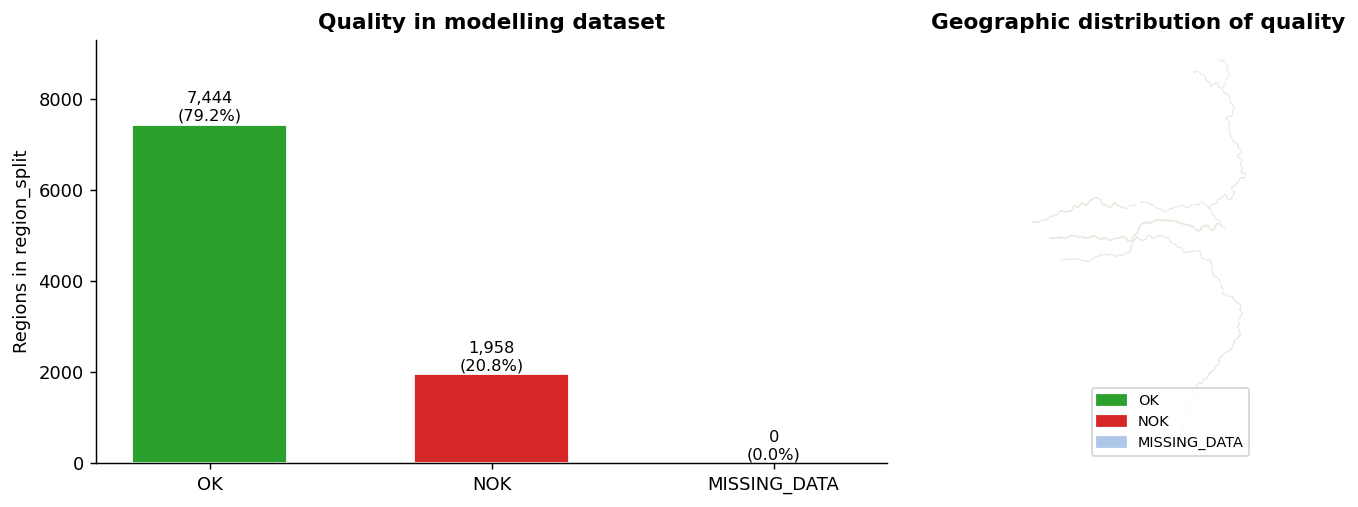

In [3]:
split_v1 = pd.read_parquet(SPLIT_V1_PATH)
print(f"region_split v1: {len(split_v1):,} regions")

# Join quality flag
quality_map = scope_quality.set_index("location_id")[QUALITY_COL]
split_v1["quality"] = split_v1.index.map(quality_map)

q_model = split_v1["quality"].value_counts().reindex(["OK", "NOK", "MISSING_DATA"]).fillna(0).astype(int)
q_model_pct = (q_model / q_model.sum() * 100).round(1)

print(f"\nQuality within existing region_split ({len(split_v1):,} regions):")
print(f"  {'Label':<15}  {'n':>6}  {'%':>6}")
for label in ["OK", "NOK", "MISSING_DATA"]:
    print(f"  {label:<15}  {int(q_model[label]):>6,}  {q_model_pct.get(label, 0):>5.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: bar chart
bars = axes[0].bar(q_model.index, q_model.values,
                   color=[PALETTE[l] for l in q_model.index], edgecolor="white", width=0.55)
for bar, lbl in zip(bars, q_model.index):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f"{int(q_model[lbl]):,}\n({q_model_pct.get(lbl,0):.1f}%)",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_ylabel("Regions in region_split")
axes[0].set_title("Quality in modelling dataset", fontweight="bold")
axes[0].set_ylim(0, q_model.max() * 1.25)

# Right: geographic map
geo_split = scope_quality[scope_quality["location_id"].isin(split_v1.index)].copy()
geo_split["color"] = geo_split[QUALITY_COL].map(PALETTE)
geo_split.plot(color=geo_split["color"], ax=axes[1], linewidth=0.2, edgecolor="white")
legend_patches = [mpatches.Patch(color=PALETTE[l], label=l) for l in ["OK","NOK","MISSING_DATA"]]
axes[1].legend(handles=legend_patches, loc="lower right", fontsize=8)
axes[1].set_title("Geographic distribution of quality", fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 3. Load processed erosion data
Re-uses the existing `processed_erosion_data.parquet` — no need to rerun DataHandler
since `punten_oever` from the old gpkg is unchanged.

In [4]:
processed = pd.read_parquet(PROCESSED_IN)
processed.index.names = ["location_id", "year"]

print(f"Loaded processed_erosion_data.parquet")
print(f"  Shape   : {processed.shape}")
print(f"  Regions : {processed.index.get_level_values(0).nunique():,}")
print(f"  Columns : {list(processed.columns)}")


Loaded processed_erosion_data.parquet
  Shape   : (30228, 2)
  Regions : 10,484
  Columns : ['distance_to_centerline', 'timesteps_since_last_measurement']


## 4. Rebuild feature table (identical to v1 preprocessing)

In [5]:
ts_counts = processed.groupby(level=0).size().rename("n_timestamps")
eligible_ids   = ts_counts[ts_counts == 3].index
inference_ids  = ts_counts[ts_counts < 3].index

print(f"Eligible (3 timestamps) : {len(eligible_ids):,}")
print(f"Inference only (< 3)    : {len(inference_ids):,}")

records = []
for location_id in eligible_ids:
    region_sorted = processed.loc[location_id].sort_index()
    years = region_sorted.index.tolist()
    dists = region_sorted[DIST_COL].tolist()
    t1, t2, t3 = years[0], years[1], years[2]
    d1, d2, d3 = dists[0], dists[1], dists[2]
    records.append({
        "location_id"   : location_id,
        "cluster"       : get_cluster(location_id),
        "n_timestamps"  : 3,
        "t1": t1, "t2": t2, "t3": t3,
        "train_span_yr" : t2 - t1,
        "test_span_yr"  : t3 - t2,
        "dist_t1"       : d1,
        "dist_t2"       : d2,
        "dist_t3"       : d3,
        "v_train"       : (d2 - d1) / (t2 - t1),
        "v_test"        : (d3 - d2) / (t3 - t2),
    })

features = pd.DataFrame(records).set_index("location_id")
print(f"\nFeature table: {features.shape}")
print(features[["v_train","v_test","dist_t2","t1","t2","t3"]].describe().round(3))


Eligible (3 timestamps) : 9,402
Inference only (< 3)    : 1,082

Feature table: (9402, 12)
        v_train    v_test   dist_t2        t1        t2        t3
count  9402.000  9402.000  9402.000  9402.000  9402.000  9402.000
mean     -0.031     0.565   121.537  2015.889  2020.889  2024.255
std       2.921     4.342    62.364     0.780     0.780     0.436
min     -41.947   -38.896     6.259  2015.000  2020.000  2024.000
25%      -0.100    -0.111    77.294  2015.000  2020.000  2024.000
50%       0.017     0.028    98.979  2016.000  2021.000  2024.000
75%       0.200     0.292   148.250  2017.000  2022.000  2025.000
max      24.650    54.812   348.500  2017.000  2022.000  2025.000


## 5. Join quality flag and apply filter
Keep only regions with `estimate_reliability_height_model == 'OK'`.

Before quality filter : 9,402
  Removed NOK         : 1,958
  Removed MISSING_DATA: 0
  Removed unknown     : 0
After quality filter  : 7,444  (79.2% retained)


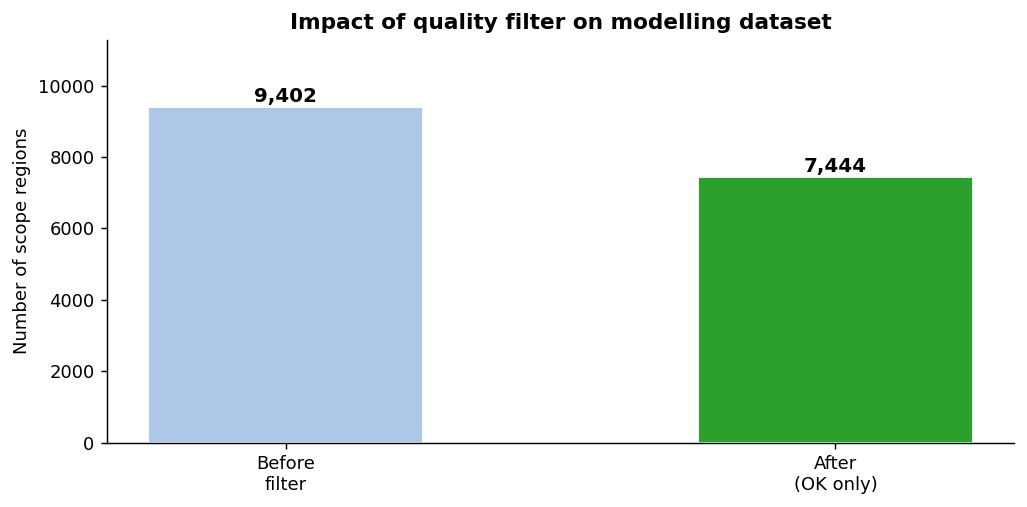

In [6]:
features["quality"] = features.index.map(quality_map)

before = len(features)
features_ok = features[features["quality"] == "OK"].copy()
after  = len(features_ok)

removed_nok     = (features["quality"] == "NOK").sum()
removed_missing = (features["quality"] == "MISSING_DATA").sum()
removed_unknown = features["quality"].isna().sum()

print(f"Before quality filter : {before:,}")
print(f"  Removed NOK         : {removed_nok:,}")
print(f"  Removed MISSING_DATA: {removed_missing:,}")
print(f"  Removed unknown     : {removed_unknown:,}")
print(f"After quality filter  : {after:,}  ({after/before*100:.1f}% retained)")

# Side-by-side comparison bar chart
fig, ax = plt.subplots(figsize=(8, 4))
labels = ["Before\nfilter", "After\n(OK only)"]
vals   = [before, after]
bar_colors = ["#aec7e8", "#2ca02c"]
bars = ax.bar(labels, vals, color=bar_colors, edgecolor="white", width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f"{v:,}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_ylabel("Number of scope regions")
ax.set_title("Impact of quality filter on modelling dataset", fontweight="bold")
ax.set_ylim(0, before * 1.2)
plt.tight_layout()
plt.show()


## 6. Cluster distribution
Eligible OK regions per river cluster, matching the output of the original preprocessing notebook.

Eligible OK regions per cluster:
  cluster      n_regions    % of OK
  ijssel1      1,810         24.3%  ████████████
  ijssel2      287            3.9%  █
  maas1        127            1.7%  
  maas2        178            2.4%  █
  maas3        2,681         36.0%  ██████████████████
  rijn         1,163         15.6%  ███████
  nederrijn    1,198         16.1%  ████████


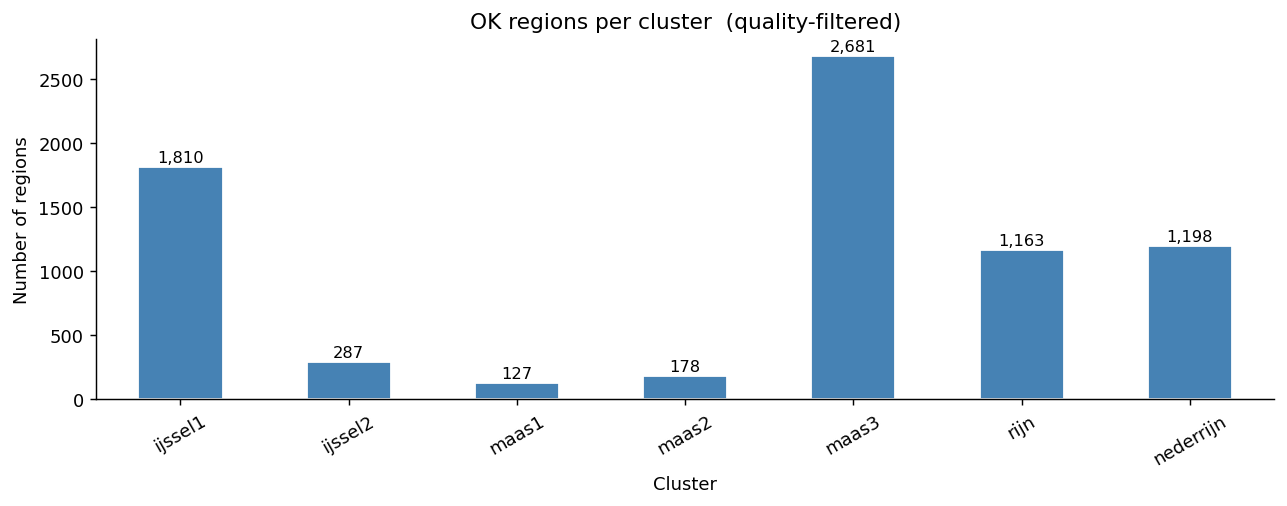

In [7]:
cluster_counts = features_ok["cluster"].value_counts().reindex(CLUSTERS + ["other"]).dropna()

print("Eligible OK regions per cluster:")
print(f"  {'cluster':<12} {'n_regions':<12} {'% of OK'}")
for cluster, count in cluster_counts.items():
    pct = count / len(features_ok) * 100
    bar = "█" * int(pct / 2)
    print(f"  {cluster:<12} {int(count):<12,} {pct:>5.1f}%  {bar}")

fig, ax = plt.subplots(figsize=(10, 4))
cluster_counts.plot.bar(ax=ax, color="steelblue", edgecolor="white")
ax.set_title("OK regions per cluster  (quality-filtered)")
ax.set_xlabel("Cluster"); ax.set_ylabel("Number of regions")
ax.tick_params(axis="x", rotation=30)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()


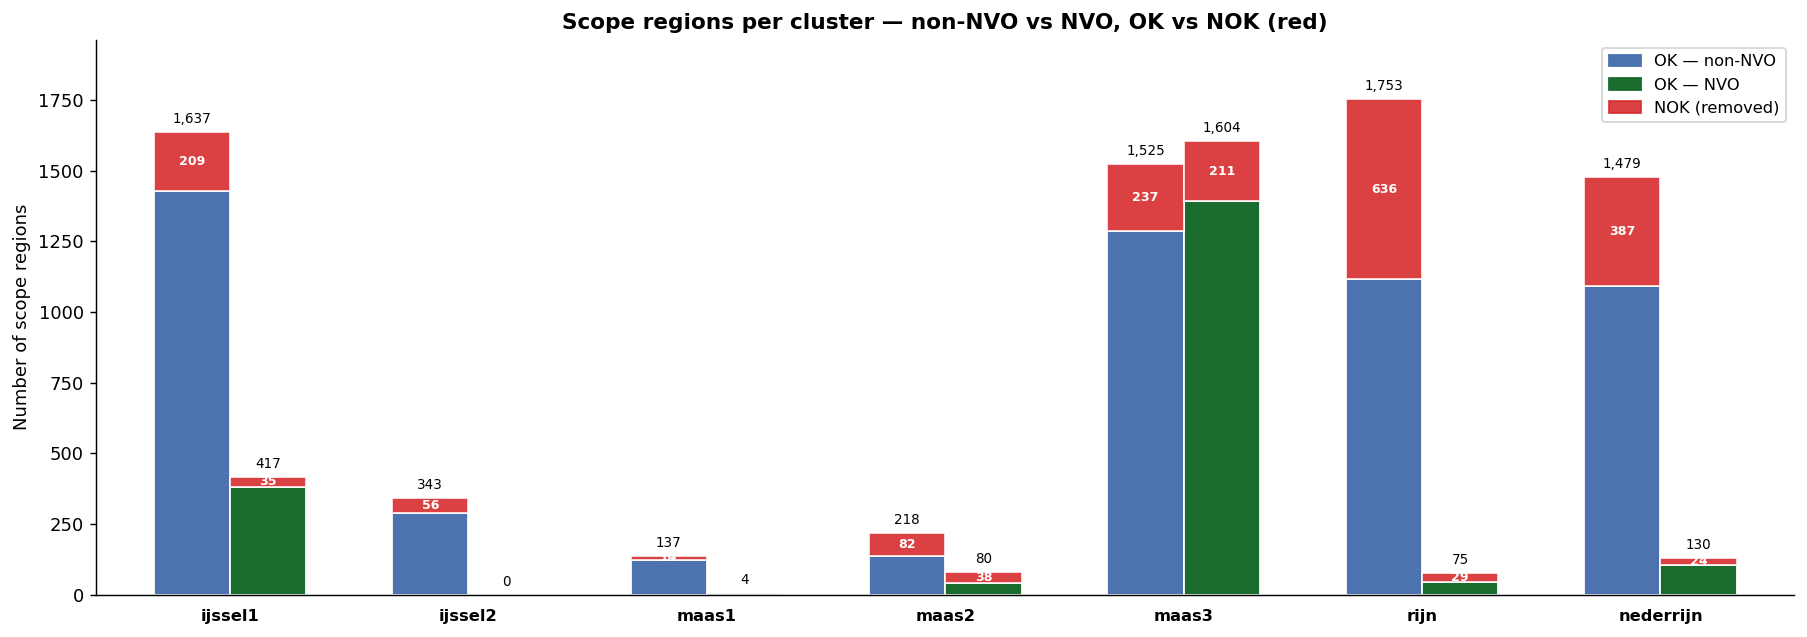

In [8]:
# ── 14-bar grouped chart: (non-NVO | NVO) × 7 clusters, each stacked OK + NOK ─
_bar = split_v1.copy()
_bar["cluster"]   = _bar.index.to_series().str.extract(r"^([a-z]+\d*)_")[0]
_bar["nvo_label"] = _bar["is_nvo"].map({False: "non-NVO", True: "NVO"})

counts = (_bar.groupby(["cluster", "nvo_label", "quality"])
              .size()
              .unstack("quality", fill_value=0)
              .reindex(columns=["OK", "NOK"], fill_value=0))

pairs    = [(c, nvo) for c in CLUSTERS for nvo in ["non-NVO", "NVO"]]
ok_vals  = np.array([counts.loc[(c, nvo), "OK"]  if (c, nvo) in counts.index else 0
                     for c, nvo in pairs])
nok_vals = np.array([counts.loc[(c, nvo), "NOK"] if (c, nvo) in counts.index else 0
                     for c, nvo in pairs])

# non-NVO = blue, NVO = dark green; NOK always red on top
bar_colors = ["#4c72b0" if nvo == "non-NVO" else "#1a6b2e" for _, nvo in pairs]

WIDTH        = 0.40
PAIR_GAP     = 0.40
CLUSTER_STEP = 1.25
# Use i//2 for cluster index (pairs are grouped: 0,1=cluster0, 2,3=cluster1, ...)
x = np.array([(i // 2) * CLUSTER_STEP + (0 if nvo == "non-NVO" else PAIR_GAP)
              for i, (_, nvo) in enumerate(pairs)])

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x, ok_vals,  color=bar_colors, edgecolor="white", width=WIDTH)
ax.bar(x, nok_vals, color="#d62728",  edgecolor="white", width=WIDTH,
       bottom=ok_vals, alpha=0.88)

top = max(ok_vals + nok_vals)

# Cluster labels via xticks at exact midpoints — reliably centred between the pair
cluster_mids = [ci * CLUSTER_STEP + PAIR_GAP / 2 for ci in range(len(CLUSTERS))]
ax.set_xticks(cluster_mids)
ax.set_xticklabels(CLUSTERS, fontsize=9, fontweight="bold")
ax.tick_params(axis="x", length=0, pad=8)

# NOK count inside red portion; total on top
for xi, (ok, nok) in zip(x, zip(ok_vals, nok_vals)):
    if nok > 0:
        ax.text(xi, ok + nok / 2, str(int(nok)),
                ha="center", va="center", fontsize=7, color="white", fontweight="bold")
    ax.text(xi, ok + nok + top * 0.012, f"{int(ok + nok):,}",
            ha="center", va="bottom", fontsize=7.5)

ax.set_xlim(x[0] - 0.5, x[-1] + 0.5)
ax.set_ylabel("Number of scope regions")
ax.set_title("Scope regions per cluster — non-NVO vs NVO, OK vs NOK (red)",
             fontweight="bold")

import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color="#4c72b0", label="OK — non-NVO"),
    mpatches.Patch(color="#1a6b2e", label="OK — NVO"),
    mpatches.Patch(color="#d62728", label="NOK (removed)", alpha=0.88),
], loc="upper right", fontsize=9)

ax.margins(y=0.12)
plt.tight_layout()
plt.show()


## 7. Add erosion volume from `erosion_vlakken_filtered`

For each scope region, match erosion polygons to:
- **Train period**: `year_before == t1` AND `year_after == t2`
- **Test period** : `year_before == t2` AND `year_after == t3`

Volume is summed over all matching erosion polygons per region (there can be multiple
non-overlapping erosion patches within one scope). Normalised by the time span gives
an annual erosion volume rate (m³/yr).

Regions with no matching erosion polygon in a window get `0` (no measured erosion volume).


In [9]:
print("Loading erosion_vlakken_filtered …")
ev_raw = gpd.read_file(str(GPKG_NEW), layer="erosion_vlakken_filtered")

# Deduplicate — identical rows appear multiple times in the layer
ev = (ev_raw[["location_id", "year_before", "year_after", "area", "erosion_volume"]]
      .drop_duplicates()
      .reset_index(drop=True))
print(f"  Raw rows : {len(ev_raw):,}")
print(f"  After dedup: {len(ev):,}")
print(f"  Unique location_ids: {ev.location_id.nunique():,}")

# ── Build per-region t1/t2/t3 lookup ─────────────────────────────────────────
t_lookup = features_ok[["t1", "t2", "t3"]].copy()
ev_joined = ev.merge(t_lookup, left_on="location_id", right_index=True, how="inner")

# Training window: year_before matches t1, year_after matches t2
train_vol = (ev_joined[
    (ev_joined["year_before"] == ev_joined["t1"]) &
    (ev_joined["year_after"]  == ev_joined["t2"])
].groupby("location_id")["erosion_volume"].sum().rename("erosion_vol_train_m3"))

# Test window: year_before matches t2, year_after matches t3
test_vol = (ev_joined[
    (ev_joined["year_before"] == ev_joined["t2"]) &
    (ev_joined["year_after"]  == ev_joined["t3"])
].groupby("location_id")["erosion_volume"].sum().rename("erosion_vol_test_m3"))

# Join and fill 0 for regions with no erosion polygons in a window
features_ok = features_ok.join(train_vol).join(test_vol)
features_ok["erosion_vol_train_m3"] = features_ok["erosion_vol_train_m3"].fillna(0)
features_ok["erosion_vol_test_m3"]  = features_ok["erosion_vol_test_m3"].fillna(0)

# Annual rates
features_ok["erosion_vol_train_rate"] = (
    features_ok["erosion_vol_train_m3"] / features_ok["train_span_yr"])
features_ok["erosion_vol_test_rate"]  = (
    features_ok["erosion_vol_test_m3"]  / features_ok["test_span_yr"])

n_with_train = (features_ok["erosion_vol_train_m3"] > 0).sum()
n_with_test  = (features_ok["erosion_vol_test_m3"]  > 0).sum()
print(f"\nRegions with measured erosion volume:")
print(f"  Train window: {n_with_train:,} / {len(features_ok):,}  ({n_with_train/len(features_ok)*100:.1f}%)")
print(f"  Test  window: {n_with_test:,}  / {len(features_ok):,}  ({n_with_test/len(features_ok)*100:.1f}%)")
print()
print("Erosion volume stats (non-zero regions only):")
nz = features_ok[features_ok["erosion_vol_test_m3"] > 0]["erosion_vol_test_m3"]
print(f"  Test vol  — mean={nz.mean():.1f}  median={nz.median():.1f}  p95={nz.quantile(.95):.1f}  max={nz.max():.1f}  m³")


Loading erosion_vlakken_filtered …
  Raw rows : 25,194
  After dedup: 24,024
  Unique location_ids: 5,267

Regions with measured erosion volume:
  Train window: 2,007 / 7,444  (27.0%)
  Test  window: 1,913  / 7,444  (25.7%)

Erosion volume stats (non-zero regions only):
  Test vol  — mean=86.3  median=20.2  p95=348.4  max=8370.0  m³


### Erosion volume distribution

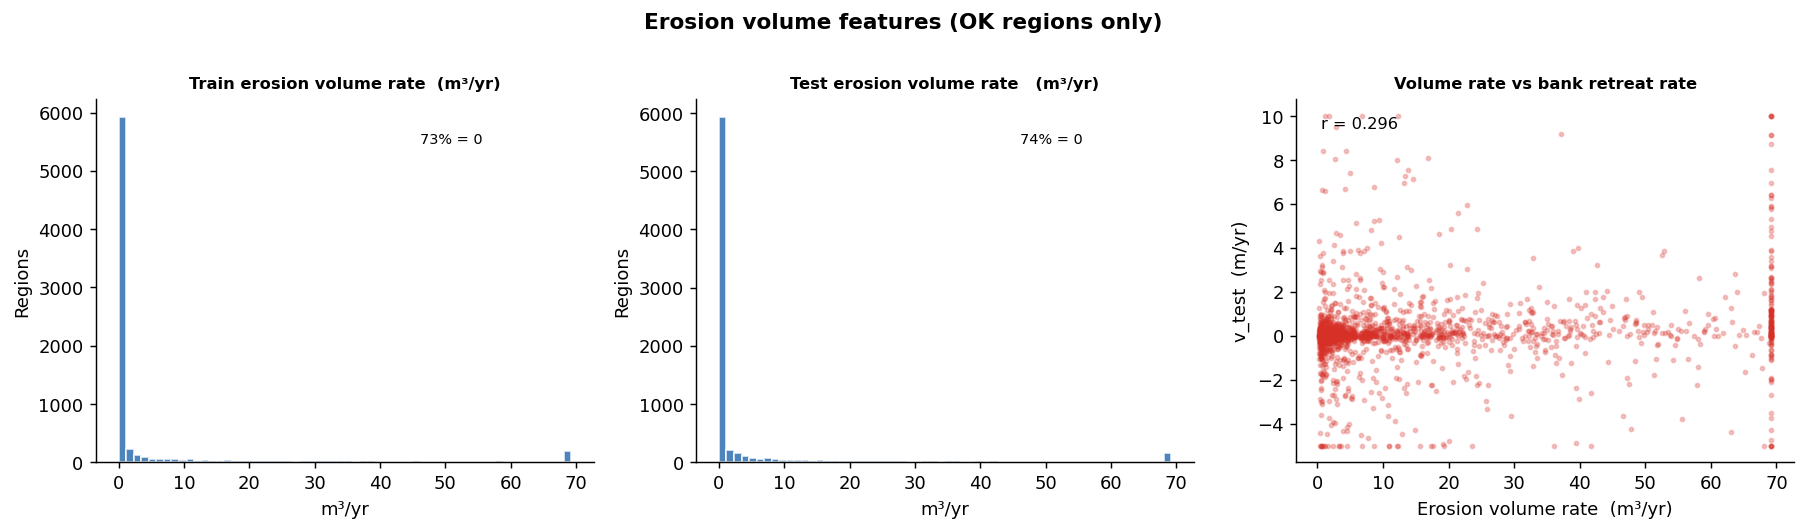

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Distribution of train and test volumes (clipped for readability)
CLIP = features_ok["erosion_vol_test_rate"].quantile(0.98)
for ax, col, title in [
    (axes[0], "erosion_vol_train_rate", "Train erosion volume rate  (m³/yr)"),
    (axes[1], "erosion_vol_test_rate",  "Test erosion volume rate   (m³/yr)"),
]:
    ax.hist(features_ok[col].clip(0, CLIP), bins=60, color="#2166ac", edgecolor="white", alpha=0.8)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xlabel("m³/yr")
    ax.set_ylabel("Regions")
    pct_zero = (features_ok[col] == 0).mean() * 100
    ax.annotate(f"{pct_zero:.0f}% = 0", xy=(0.65, 0.88), xycoords="axes fraction", fontsize=8)

# Scatter: erosion_vol_test_rate vs v_test
ax = axes[2]
nonzero = features_ok[features_ok["erosion_vol_test_rate"] > 0]
ax.scatter(nonzero["erosion_vol_test_rate"].clip(0, CLIP),
           nonzero["v_test"].clip(-5, 10),
           s=5, alpha=0.25, color="#d73027")
ax.set_xlabel("Erosion volume rate  (m³/yr)")
ax.set_ylabel("v_test  (m/yr)")
ax.set_title("Volume rate vs bank retreat rate", fontsize=9, fontweight="bold")
r = nonzero["erosion_vol_test_rate"].corr(nonzero["v_test"])
ax.annotate(f"r = {r:.3f}", xy=(0.05, 0.92), xycoords="axes fraction", fontsize=9)

plt.suptitle("Erosion volume features (OK regions only)", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 7. Carry over `is_nvo` from v1
This flag lives in the existing `region_split.parquet` and is unchanged.

In [11]:
if "is_nvo" in split_v1.columns:
    features_ok["is_nvo"] = features_ok.index.map(split_v1["is_nvo"]).fillna(False).astype(bool)
    n_nvo = features_ok["is_nvo"].sum()
    print(f"is_nvo carried over: {n_nvo:,} NVO regions  ({n_nvo/len(features_ok)*100:.1f}%)")
else:
    features_ok["is_nvo"] = False
    print("Warning: is_nvo not found in v1 split, defaulting to False")


is_nvo carried over: 1,973 NVO regions  (26.5%)


## 10. Stratified 80/20 train/test split
Fresh split on the quality-filtered 7,444 OK regions, stratified by cluster.
This is independent of the v1 split so the hold-out set is unbiased with
respect to the quality filter.

In [12]:
train_idx, test_idx = train_test_split(
    features_ok.index,
    test_size    = TEST_SIZE,
    random_state = RANDOM_SEED,
    stratify     = features_ok["cluster"],
)

features_ok["split"] = "train"
features_ok.loc[test_idx, "split"] = "test"

split_counts = features_ok.groupby(["cluster", "split"]).size().unstack(fill_value=0)
split_counts["total"]   = split_counts.sum(axis=1)
split_counts["test_%"]  = (split_counts["test"]  / split_counts["total"] * 100).round(1)
split_counts["train_%"] = (split_counts["train"] / split_counts["total"] * 100).round(1)
totals = split_counts[["train", "test", "total"]].sum()
totals["test_%"]  = round(totals["test"]  / totals["total"] * 100, 1)
totals["train_%"] = round(totals["train"] / totals["total"] * 100, 1)
split_counts.loc["TOTAL"] = totals

print("Split result per cluster:")
display(split_counts[["train", "train_%", "test", "test_%", "total"]])


Split result per cluster:


split,train,train_%,test,test_%,total
cluster,,,,,
ijssel1,1448.0,80.0,362.0,20.0,1810.0
ijssel2,230.0,80.1,57.0,19.9,287.0
maas1,102.0,80.3,25.0,19.7,127.0
maas2,142.0,79.8,36.0,20.2,178.0
maas3,2145.0,80.0,536.0,20.0,2681.0
nederrijn,958.0,80.0,240.0,20.0,1198.0
rijn,930.0,80.0,233.0,20.0,1163.0
TOTAL,5955.0,80.0,1489.0,20.0,7444.0


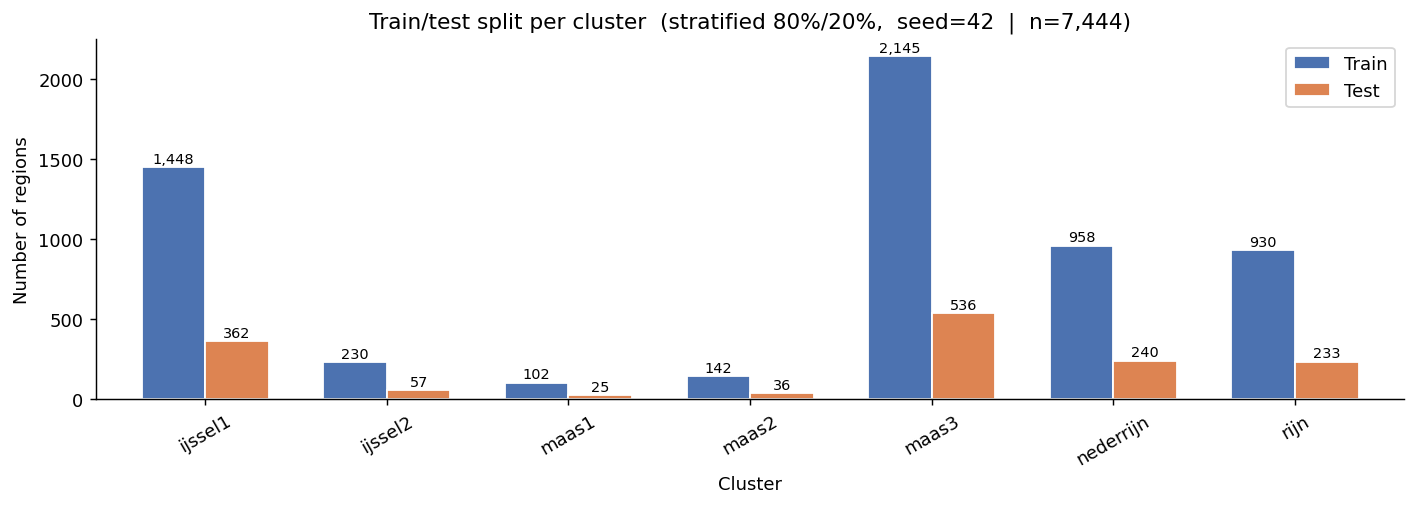

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))
split_counts.drop("TOTAL")[["train", "test"]].plot.bar(
    ax=ax, color=["#4c72b0", "#dd8452"], edgecolor="white", width=0.7
)
ax.set_title(
    f"Train/test split per cluster  "
    f"(stratified {1-TEST_SIZE:.0%}/{TEST_SIZE:.0%},  seed={RANDOM_SEED}  |  "
    f"n={len(features_ok):,})"
)
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of regions")
ax.tick_params(axis="x", rotation=30)
ax.legend(["Train", "Test"])
for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 8,
                f"{int(h):,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()


### Train vs test distribution check
Verify that the random stratified split produces balanced `v_train` and `v_test` distributions.

Distribution check — train and test should look similar:
                      value
train v_train mean    0.096
test  v_train mean    0.009
train v_test  mean    0.147
test  v_test  mean    0.162
train dist_t2 mean  114.174
test  dist_t2 mean  115.044


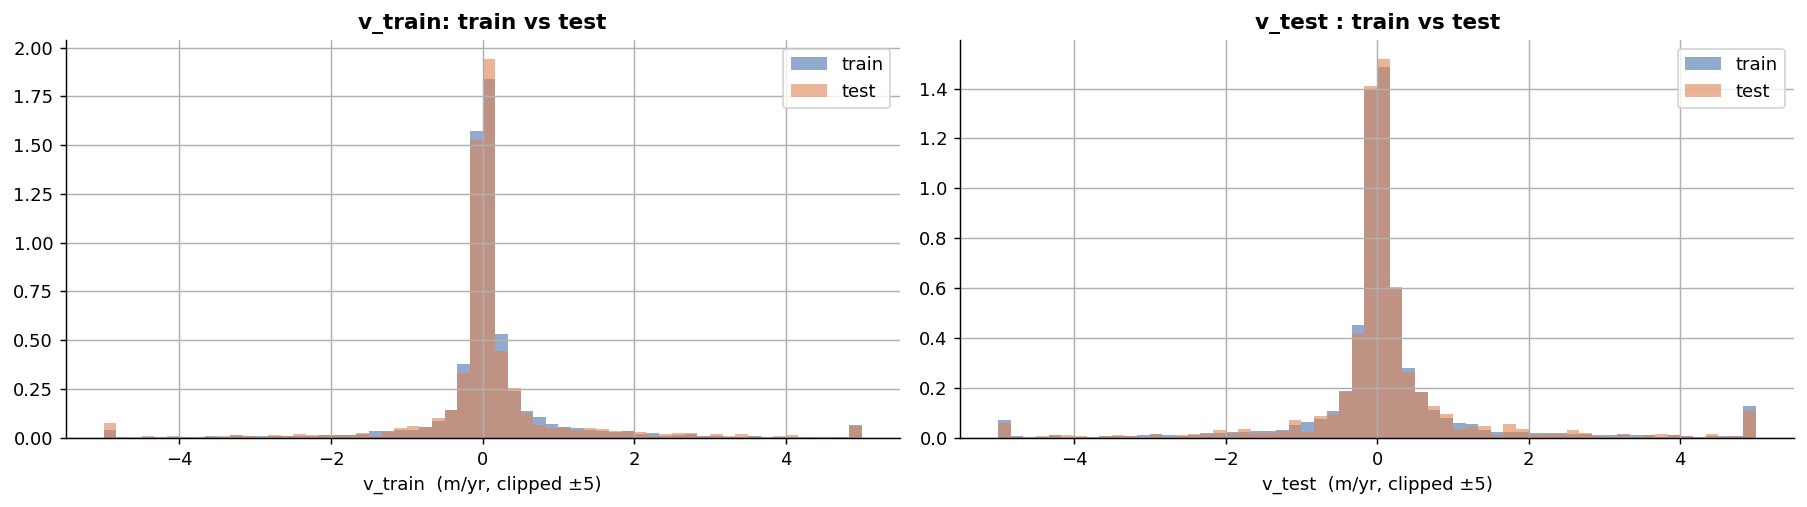

In [14]:
_train = features_ok[features_ok["split"] == "train"]
_test  = features_ok[features_ok["split"] == "test"]

check_df = pd.DataFrame({
    "train v_train mean" : [_train["v_train"].mean()],
    "test  v_train mean" : [_test["v_train"].mean()],
    "train v_test  mean" : [_train["v_test"].mean()],
    "test  v_test  mean" : [_test["v_test"].mean()],
    "train dist_t2 mean" : [_train["dist_t2"].mean()],
    "test  dist_t2 mean" : [_test["dist_t2"].mean()],
}).T.rename(columns={0: "value"})
print("Distribution check — train and test should look similar:")
print(check_df.round(3).to_string())

CLIP = 5
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title in [
    (axes[0], "v_train", "v_train: train vs test"),
    (axes[1], "v_test",  "v_test : train vs test"),
]:
    _train[col].clip(-CLIP, CLIP).hist(bins=60, ax=ax, alpha=0.6,
                                       color="#4c72b0", label="train", density=True)
    _test[col].clip(-CLIP, CLIP).hist( bins=60, ax=ax, alpha=0.6,
                                       color="#dd8452", label="test",  density=True)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(f"{col}  (m/yr, clipped ±{CLIP})")
    ax.legend()
plt.tight_layout(); plt.show()


## 9. Distribution sanity check — v1 vs v2

Mean values — v1 (all) vs v2 (OK only):
          v1 all  v2 OK-only
v_train   -0.031       0.078
v_test     0.565       0.150
dist_t2  121.537     114.348


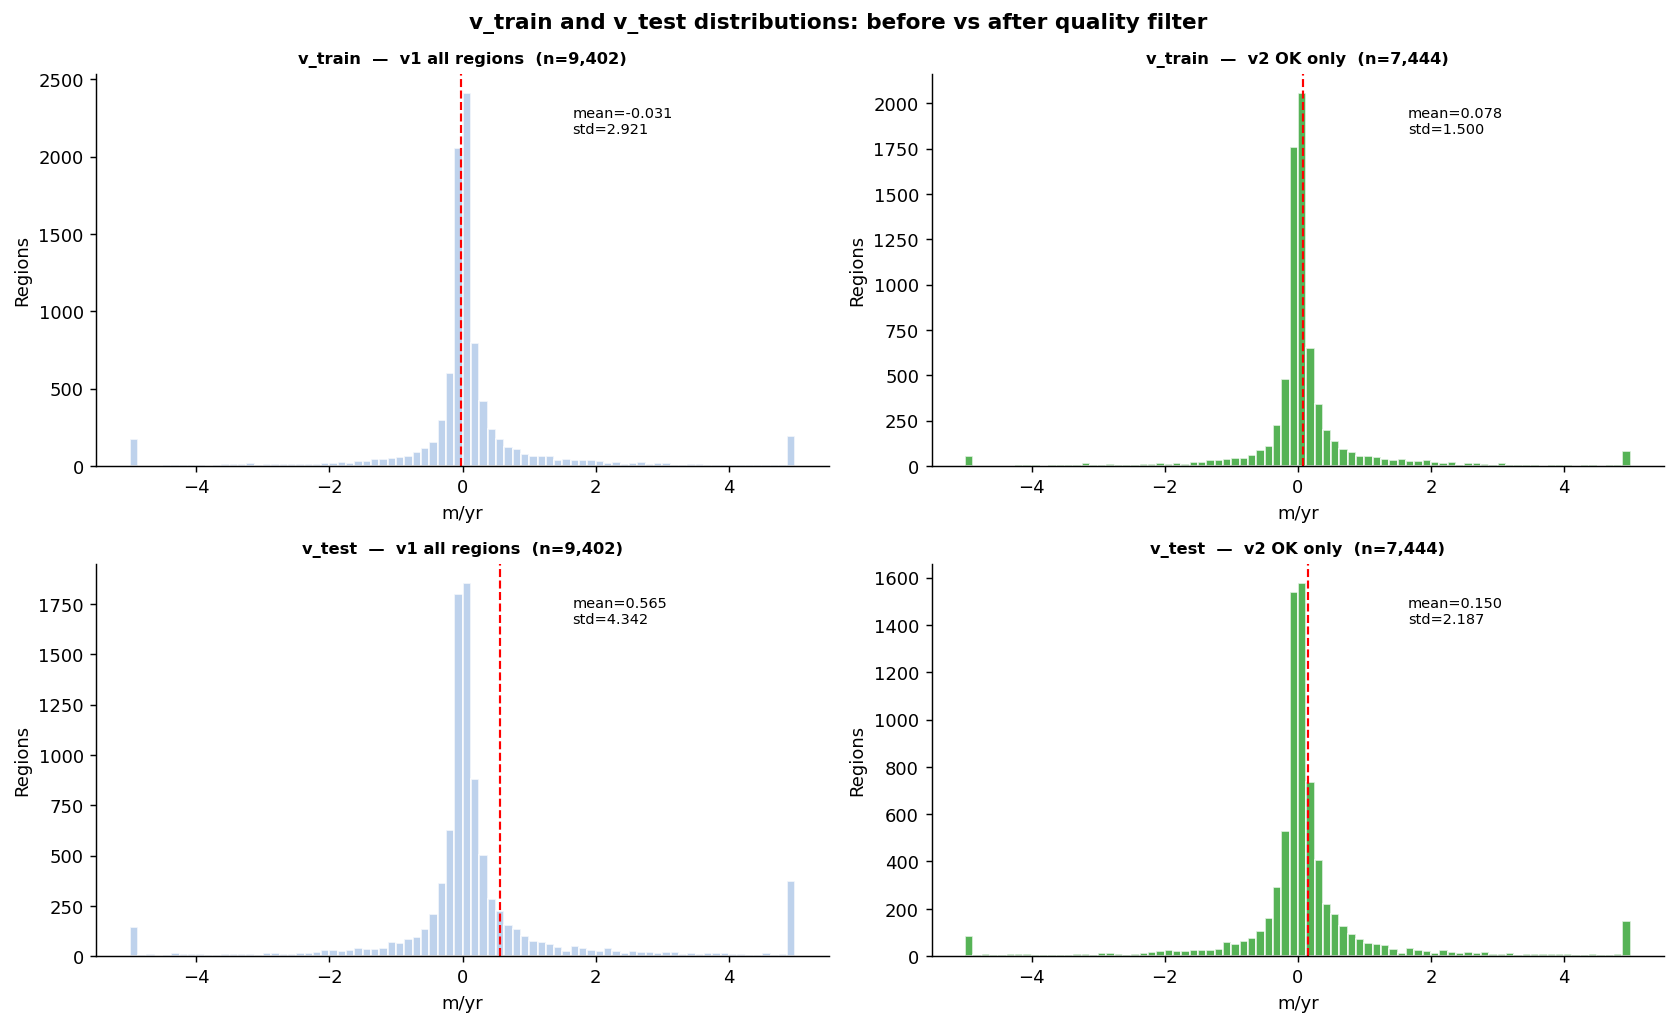

In [15]:
check = pd.DataFrame({
    "v1 all"       : split_v1[["v_train","v_test","dist_t2"]].mean(),
    "v2 OK-only"   : features_ok[["v_train","v_test","dist_t2"]].mean(),
}).round(3)
print("Mean values — v1 (all) vs v2 (OK only):")
print(check.to_string())

CLIP = 5
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, col in enumerate(["v_train", "v_test"]):
    for ax, (df, label, color) in zip(
        axes[row],
        [(split_v1, "v1 all regions", "#aec7e8"),
         (features_ok, "v2 OK only", "#2ca02c")]
    ):
        ax.hist(df[col].clip(-CLIP, CLIP), bins=80, color=color, edgecolor="white", alpha=0.8)
        ax.set_title(f"{col}  —  {label}  (n={len(df):,})", fontsize=9, fontweight="bold")
        ax.set_xlabel("m/yr"); ax.set_ylabel("Regions")
        ax.axvline(df[col].mean(), color="red", lw=1.2, linestyle="--")
        ax.annotate(f"mean={df[col].mean():.3f}\nstd={df[col].std():.3f}",
                    xy=(0.65, 0.85), xycoords="axes fraction", fontsize=8)

plt.suptitle("v_train and v_test distributions: before vs after quality filter", fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Save outputs

In [16]:
# region_split_v2: same shape as v1 + quality + erosion_volume columns
split_v2_cols = [
    "cluster", "n_timestamps", "t1", "t2", "t3",
    "train_span_yr", "test_span_yr",
    "dist_t1", "dist_t2", "dist_t3",
    "v_train", "v_test",
    "is_nvo", "quality", "split",
    "erosion_vol_train_m3", "erosion_vol_test_m3",
    "erosion_vol_train_rate", "erosion_vol_test_rate",
]
region_split_v2 = features_ok[[c for c in split_v2_cols if c in features_ok.columns]]
region_split_v2.to_parquet(SPLIT_V2_OUT)
print(f"Saved: {SPLIT_V2_OUT.name}  {region_split_v2.shape}")

# ── region_features_v2 ───────────────────────────────────────────────────────
# Rebuild region_features by re-running the feature engineering pipeline
# (same logic as 20260127_explore_features.ipynb build section)

import src.constants as CONST
from pathlib import Path

SOIL_PATH = PATHS.DATA_DIR / "01_raw/soil/BRO_DownloadBodemkaart.gpkg"
VEG_PATH  = PATHS.DATA_DIR / "02_processed/wfs_context/vegetatielegger.gpkg"
LU_PATH   = PATHS.DATA_DIR / "02_processed/wfs_context/land_use.gpkg"
DISC_DIR  = PATHS.DATA_DIR / "timeseries/discharge"
WS_PATH   = PATHS.DATA_DIR / "02_processed/water_stations/water_stations_for_modeling.gpkg"
SCOPE_PATH = PATHS.DATA_DIR / "01_raw/erosion/wocu_output_fase2_20260210.gpkg"

def encode_col(series, name):
    known = CONST.KNOWN_CATEGORIES.get(name, [])
    mapping = {v: i for i, v in enumerate(known)}
    unknown = CONST.DEFAULT_UNKNOWN_CATEGORY_LABEL
    return series.map(lambda x: mapping.get(x, unknown))

feat = region_split_v2.copy()
feat["river"] = feat.index.to_series().str.extract(r"^([a-z]+\d*)_")[0]

# ── vegetation ────────────────────────────────────────────────────────────────
try:
    veg = gpd.read_file(str(VEG_PATH), layer="rws_vegetatielegger:vegetatieklassen")
    veg_map = (veg.dropna(subset=["vlklasse"])
                  .groupby("scope_region_id")["vlklasse"]
                  .agg(lambda x: x.value_counts().index[0]))
    feat["vegetation_class"] = feat.index.map(veg_map)
    print(f"  vegetation: {feat['vegetation_class'].notna().sum()} regions assigned")
except Exception as e:
    print(f"  vegetation: {e}"); feat["vegetation_class"] = None

# ── land use ──────────────────────────────────────────────────────────────────
try:
    lu = gpd.read_file(str(LU_PATH), layer="BrpGewas")
    lu_map = (lu.dropna(subset=["category"])
                .groupby("scope_region_id")["category"]
                .agg(lambda x: x.value_counts().index[0]))
    feat["land_use"] = feat.index.map(lu_map)
    print(f"  land_use: {feat['land_use'].notna().sum()} regions assigned")
except Exception as e:
    print(f"  land_use: {e}"); feat["land_use"] = None

# ── soil + discharge + nearest_station — carry over from v1 ───────────────────
# These were computed correctly in region_features.parquet (v1) via the
# 20260127_explore_features notebook. Re-using avoids re-running the heavy
# spatial intersection and discharge stats loop.
FEATURES_V1_PATH = PATHS.DATA_DIR / "02_processed/erosion/region_features.parquet"
feat_v1 = pd.read_parquet(FEATURES_V1_PATH)
carry_cols = ["soil_group", "nearest_station", "peak_p99", "days_above_p90"]
for col in carry_cols:
    if col in feat_v1.columns:
        feat[col] = feat.index.map(feat_v1[col])
assigned = {c: feat[c].notna().sum() for c in carry_cols if c in feat.columns}
print(f"  Carried over from v1: {assigned}")






Saved: region_split_v2.parquet  (7444, 19)
  vegetation: 5420 regions assigned
  land_use: 2871 regions assigned
  Carried over from v1: {'soil_group': np.int64(6639), 'nearest_station': np.int64(7444), 'peak_p99': np.int64(7444), 'days_above_p90': np.int64(7444)}


In [17]:
# ── curvature (Menger curvature at n=3,5,8) ────────────────────────────────────
from src.data.curvature import add_curvature_features, curvature_feature_cols

scope_for_curvature = scope_quality[scope_quality["location_id"].isin(feat.index)].copy()
scope_for_curvature["river"] = scope_for_curvature["location_id"].str.extract(r"^([a-z]+\d*)_")[0]
scope_for_curvature["bank"] = scope_for_curvature["location_id"].str.extract(r"_([lr])_")[0]
scope_for_curvature["chainage"] = scope_for_curvature["location_id"].str.extract(r"_(\d+)_\d+$")[0].astype(float)
scope_for_curvature = scope_for_curvature[scope_for_curvature["river"] != "ngeul"]
scope_for_curvature["chainage"] = scope_for_curvature["chainage"].fillna(
    scope_for_curvature.groupby(["river", "bank"]).cumcount().astype(float)
)

scope_curve = add_curvature_features(scope_for_curvature.set_index("location_id"))
curv_cols = curvature_feature_cols()
feat[curv_cols] = scope_curve[curv_cols].reindex(feat.index).values
print(f"  curvature: {(feat[curv_cols].notna().all(axis=1)).sum()} regions assigned")

  curvature: 7444 regions assigned


In [21]:
# ── Inspect curvature results ───────────────────────────────────────────────────
# DataFrame: summary stats and sample
curv_cols = curvature_feature_cols()
print("Curvature columns summary:")
display(feat[curv_cols].describe().round(6))

print("\nSample (first 5 rows):")
display(feat[["river"] + curv_cols].head() if "river" in feat.columns else feat[curv_cols].head())

Curvature columns summary:


,curvature_n3,curvature_n5,curvature_n8,bend_side_n3,bend_side_n5,bend_side_n8,bend_exposure_n3,bend_exposure_n5,bend_exposure_n8
count,7444.000000,7444.000000,7444.000000,7444.000000,7444.000000,7444.000000,7444.000000,7444.000000,7444.000000
mean,0.000259,0.000225,0.000186,0.022300,0.018538,0.015046,-0.000014,-0.000010,-0.000006
std,0.000227,0.000192,0.000157,0.997935,0.998012,0.998071,0.000344,0.000296,0.000243
min,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-0.002042,-0.001315,-0.000934
25%,0.000088,0.000080,0.000067,-1.000000,-1.000000,-1.000000,-0.000196,-0.000176,-0.000143
50%,0.000194,0.000172,0.000142,1.000000,1.000000,1.000000,0.000005,0.000005,0.000003
75%,0.000376,0.000322,0.000267,1.000000,1.000000,1.000000,0.000192,0.000170,0.000139
max,0.002042,0.001315,0.000934,1.000000,1.000000,1.000000,0.001222,0.000963,0.000759



Sample (first 5 rows):


,river,curvature_n3,curvature_n5,curvature_n8,bend_side_n3,bend_side_n5,bend_side_n8,bend_exposure_n3,bend_exposure_n5,bend_exposure_n8
location_id,,,,,,,,,,
ijssel1_l_0010_0020,ijssel1,0.000000,0.000000,0.000000,-0.0,-0.0,-0.0,-0.000000,-0.000000,-0.000000
ijssel1_l_0020_0030,ijssel1,0.000149,0.000223,0.000268,1.0,1.0,1.0,0.000149,0.000223,0.000268
ijssel1_l_0050_0056,ijssel1,0.000347,0.000351,0.000356,1.0,1.0,1.0,0.000347,0.000351,0.000356
ijssel1_l_0060_0070,ijssel1,0.000409,0.000387,0.000377,1.0,1.0,1.0,0.000409,0.000387,0.000377
ijssel1_l_0070_0080,ijssel1,0.000418,0.000379,0.000369,1.0,1.0,1.0,0.000418,0.000379,0.000369


In [22]:
# ── encode ────────────────────────────────────────────────────────────────────
for col in ["river", "vegetation_class", "land_use", "soil_group"]:
    feat[f"{col}_enc"] = encode_col(feat[col], col)

feat.to_parquet(FEATURES_V2_OUT)
print(f"\nSaved: {FEATURES_V2_OUT.name}  {feat.shape}")
print("\nNew columns in v2:")
new_cols = ["quality","erosion_vol_train_m3","erosion_vol_test_m3",
            "erosion_vol_train_rate","erosion_vol_test_rate"]
print(feat[[c for c in new_cols if c in feat.columns]].describe().round(2))


Saved: region_features_v2.parquet  (7444, 39)

New columns in v2:
       erosion_vol_train_m3  erosion_vol_test_m3  erosion_vol_train_rate  \
count               7444.00              7444.00                 7444.00   
mean                  36.40                22.18                    7.28   
std                  218.55               148.69                   43.71   
min                    0.00                 0.00                    0.00   
25%                    0.00                 0.00                    0.00   
50%                    0.00                 0.00                    0.00   
75%                    1.86                 1.25                    0.37   
max                 9671.10              8370.00                 1934.22   

       erosion_vol_test_rate  
count                7444.00  
mean                    6.22  
std                    46.13  
min                     0.00  
25%                     0.00  
50%                     0.00  
75%                     0.39  


## Summary

In [23]:
print("=" * 55)
print("  Preprocessing v2 — Summary")
print("=" * 55)
print(f"  Input gpkg (bank points): {GPKG_OLD.name}")
print(f"  Quality source          : {GPKG_NEW.name}")
print()
print(f"  Regions v1 (all)        : {len(split_v1):,}")
print(f"    removed NOK           : {removed_nok:,}")
print(f"    removed MISSING_DATA  : {removed_missing:,}")
print(f"    removed unknown       : {removed_unknown:,}")
print(f"  Regions v2 (OK only)    : {len(region_split_v2):,}  "
      f"({len(region_split_v2)/len(split_v1)*100:.1f}% retained)")
print()
print(f"  train / test            : "
      f"{(region_split_v2.split=='train').sum():,} / "
      f"{(region_split_v2.split=='test').sum():,}")
print()
print(f"  Output: {SPLIT_V2_OUT.name}   {region_split_v2.shape}")
print(f"  Output: {FEATURES_V2_OUT.name}  {feat.shape}")
print("=" * 55)


  Preprocessing v2 — Summary
  Input gpkg (bank points): wocu_output_fase2_20260210.gpkg
  Quality source          : wocu_post_processed_fase2_20260310.gpkg

  Regions v1 (all)        : 9,402
    removed NOK           : 1,958
    removed MISSING_DATA  : 0
    removed unknown       : 0
  Regions v2 (OK only)    : 7,444  (79.2% retained)

  train / test            : 5,955 / 1,489

  Output: region_split_v2.parquet   (7444, 19)
  Output: region_features_v2.parquet  (7444, 39)
